In [6]:
import sys, random
import numpy as np
import torch
sys.path.insert(0, ".")

import transformers
from pyfaidx import Fasta
from DNABERT2_modules import load_dnabert2_mlm

print(f"transformers version: {transformers.__version__}")

model, tokenizer = load_dnabert2_mlm()

device = next(model.parameters()).device
print(f"device     : {device}")
print(f"vocab size : {model.config.vocab_size}")

transformers version: 4.42.4
device     : cuda:0
vocab size : 4096


In [13]:
FASTA_PATH = "/home/andrew.dickson/rice_data/Oryza_sativa.IRGSP-1.0.dna_sm.toplevel.fa"
SEQ_LEN    = 1000
N_SEQS     = 300
MAX_N_FRAC = 0.10   # skip windows with >10% N's (soft-masked regions)
SEED       = 42

rng = random.Random(SEED)
ref = Fasta(FASTA_PATH)

# Mirror dataset.py: only use numeric chromosome keys (1–12 for rice)
chroms = [name for name in ref.keys() if name.isdigit()]
print(f"chromosomes : {chroms}")

sequences = []
attempts  = 0
while len(sequences) < N_SEQS:
    attempts += 1
    chrom     = rng.choice(chroms)
    chrom_len = len(ref[chrom])
    if chrom_len < SEQ_LEN:
        continue
    start = rng.randint(0, chrom_len - SEQ_LEN)
    seq   = str(ref[chrom][start : start + SEQ_LEN]).upper()
    if seq.count("N") / len(seq) > MAX_N_FRAC:
        continue
    sequences.append(seq)

print(f"sampled {len(sequences)} sequences (rejected {attempts - N_SEQS} high-N windows)")

chromosomes : ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
sampled 300 sequences (rejected 0 high-N windows)


In [14]:
MASK_ID = tokenizer.mask_token_id

@torch.no_grad()
def pseudo_perplexity(seq: str, sub_batch: int = 64) -> float:
    """
    Pseudo-perplexity via one-token-at-a-time masking (Salazar et al. 2020).

    For every non-special token position i, mask it and record
    log P(true_token_i | context). Returns exp(-mean log P).
    A well-trained model should be far below vocab_size (~4096).
    """
    enc       = tokenizer(seq, return_tensors="pt")
    input_ids = enc["input_ids"][0]       # (T,)
    attn_mask = enc["attention_mask"][0]  # (T,)
    T         = input_ids.shape[0]

    # Skip [CLS] at 0 and [SEP] at T-1
    positions = list(range(1, T - 1))

    log_probs = []
    for start in range(0, len(positions), sub_batch):
        batch_pos = positions[start : start + sub_batch]
        B         = len(batch_pos)

        ids  = input_ids.unsqueeze(0).expand(B, -1).clone()   # (B, T)
        mask = attn_mask.unsqueeze(0).expand(B, -1)           # (B, T)
        for j, pos in enumerate(batch_pos):
            ids[j, pos] = MASK_ID

        logits      = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
        log_softmax = torch.log_softmax(logits, dim=-1)  # (B, T, vocab)

        for j, pos in enumerate(batch_pos):
            log_probs.append(log_softmax[j, pos, input_ids[pos]].item())

    return float(np.exp(-np.mean(log_probs)))


# Sanity check: one sequence
ppl_example = pseudo_perplexity(sequences[0])
print(f"example pseudo-PPL : {ppl_example:.3f}")
print(f"(random baseline   : {model.config.vocab_size})")

example pseudo-PPL : 525.072
(random baseline   : 4096)


In [15]:
from tqdm.auto import tqdm

ppls = np.array([pseudo_perplexity(seq) for seq in tqdm(sequences, desc="pseudo-PPL")])

print(f"n        : {len(ppls)}")
print(f"mean PPL : {ppls.mean():.3f}")
print(f"median   : {np.median(ppls):.3f}")
print(f"std      : {ppls.std():.3f}")
print(f"min      : {ppls.min():.3f}")
print(f"max      : {ppls.max():.3f}")

pseudo-PPL: 100%|██████████| 300/300 [02:21<00:00,  2.12it/s]

n        : 300
mean PPL : 398.744
median   : 412.584
std      : 177.403
min      : 2.609
max      : 866.723


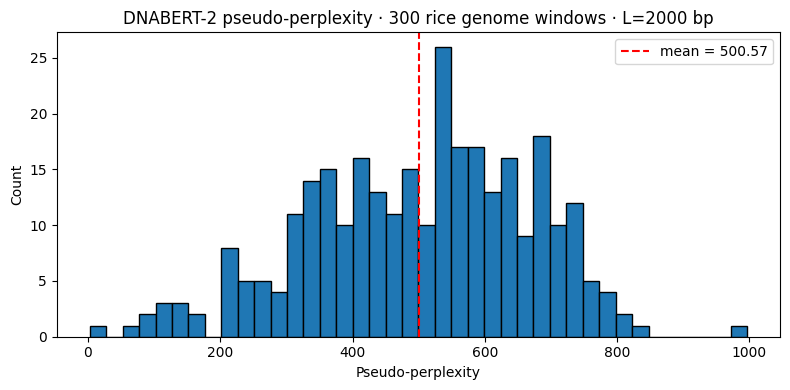

saved pseudo_ppl_hist.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ppls, bins=40, edgecolor="black")
ax.axvline(ppls.mean(), color="red", linestyle="--", label=f"mean = {ppls.mean():.2f}")
ax.set_xlabel("Pseudo-perplexity")
ax.set_ylabel("Count")
ax.set_title(
    f"DNABERT-2 pseudo-perplexity · {len(ppls)} rice genome windows · L={SEQ_LEN} bp"
)
ax.legend()
fig.tight_layout()
fig.savefig("pseudo_ppl_hist.png", dpi=150)
plt.show()
print("saved pseudo_ppl_hist.png")